# 10 - EDA & PCA: Motor Repertoire Expansion

**Purpose:** Evaluate whether the intervention leads to measurable increase in behavioral complexity and spatial exploration. Compare T1 (Baseline), T2 (Peak Effect), and T3 (Afterglow/Recovery) using a **3-branch** approach:

- **Branch A (Dynamics):** `__zeroed_rel_...__omega_mag` — rotational speed and rhythmic complexity.
- **Branch B (Pose):** Quaternion components ($q_w, q_x, q_y, q_z$) per joint — body shapes and postures.
- **Branch C (Reach):** `__lin_rel_p[xyz]` (Hips at origin) — volumetric reach.

All processing logic lives in **EDA_PCA.py**; this notebook handles configuration, calls, and display (Numerical Verification Table, 12-Plot Dashboard).

---

In [14]:
# ============================================================
# Phase 0: Configuration & Integrity Checks
# ============================================================
import os
import sys
from pathlib import Path

if os.path.basename(os.getcwd()) == "notebooks":
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
else:
    PROJECT_ROOT = os.path.abspath(os.getcwd())
SRC_PATH = os.path.join(PROJECT_ROOT, "src")
if SRC_PATH not in sys.path:
    sys.path.insert(0, SRC_PATH)

import pandas as pd
from EDA_PCA import run_integrity_checks

# Subject 671, batch from JSON
SUBJECT_ID = "651_p3_r1"
BATCH_CONFIG_PATH = Path(PROJECT_ROOT) / "batch_configs" / f"subject_{SUBJECT_ID}_all.json"

result = run_integrity_checks(
    batch_config=str(BATCH_CONFIG_PATH),
    project_root=PROJECT_ROOT,
)

# Store available timepoints for downstream use (dynamic: works with 2 or 3 sessions)
AVAILABLE_TIMEPOINTS = result.get("available_timepoints", ["T1", "T2", "T3"])

# Numerical Verification Table
table_rows = result["table_rows"]
if table_rows:
    df_verify = pd.DataFrame(table_rows)
    df_verify.rename(columns={"n_omega": "ω cols", "n_q": "q cols", "n_xyz": "XYZ cols"}, inplace=True)
    # Add duration column: Frames / fs
    if "Frames" in df_verify.columns and "Median fs (Hz)" in df_verify.columns:
        df_verify["Duration (s)"] = (df_verify["Frames"] / df_verify["Median fs (Hz)"]).round(1)
    col_order = ["Session ID", "Frames", "Median fs (Hz)", "Duration (s)", "Max Gap (ms)", "ω cols", "q cols", "XYZ cols"]
    df_verify = df_verify[[c for c in col_order if c in df_verify.columns]]
    display(df_verify)
else:
    print("No table rows (missing parquet files or insufficient sessions).")

# Warnings (non-blocking — e.g. one timepoint missing)
for warn in result.get("warnings", []):
    print(f"  ⚠️  {warn}")

# Errors (blocking)
for err in result["errors"]:
    print(f"  ❌ {err}")

# Final status summary
n_sessions = len(AVAILABLE_TIMEPOINTS)
tp_label = " / ".join(AVAILABLE_TIMEPOINTS)
if result["passed"]:
    status_str = f"**PASS** — {n_sessions} session(s): {tp_label}"
else:
    status_str = f"**FAIL** — see errors above"
print(f"\n{'='*50}")
print(f"Phase 0 Status: {status_str}")
print(f"{'='*50}")

,Session ID,Frames,Median fs (Hz),Duration (s),Max Gap (ms),ω cols,q cols,XYZ cols
0,T1,7345,120.0,61.2,8.33,19,76,57
1,T2,8904,120.0,74.2,8.33,19,76,57
2,T3,8649,120.0,72.1,8.33,19,76,57



Phase 0 Status: **PASS** — 3 session(s): T1 / T2 / T3


## Pre-Processing: Time-Window Slicer

Standardize the analysis window for all sessions. Discard the first `TRIM_START_SEC` seconds (warm-up) and keep only `ANALYSIS_DURATION_SEC` seconds. This ensures T1, T2, T3 are compared over an identical time budget. Set `ENABLE_TRIMMING = False` to skip.

In [15]:
# ============================================================
# Pre-Processing: Time-Window Slicer
# ============================================================
# Standardize analysis window: discard warm-up, keep fixed duration.
# Toggle ENABLE_TRIMMING = False to use full sessions.
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
from EDA_PCA import load_batch_config, get_session_mapping

# --- Configuration ---
TRIM_START_SEC = 10        # Seconds to discard from the beginning (warm-up)
ANALYSIS_DURATION_SEC = 50 # Seconds to keep for analysis 
ENABLE_TRIMMING = True     # Master toggle

# --- Joint Filter for PCA ---
# Control which joints enter PCA for ALL branches (Dynamics, Pose, Reach).
# By default ALL joints are included (both lists are None).
# Set ONE of the two lists — not both:
#   INCLUDE_JOINTS = ["Hips", "Spine", ...]  -> only these joints enter PCA
#   EXCLUDE_JOINTS = ["LeftFoot", ...]        -> these joints are removed; rest kept
INCLUDE_JOINTS = None  # e.g. ["Hips","Spine","Spine1","Neck","Head","LeftShoulder","RightShoulder","LeftArm","RightArm","LeftForeArm","RightForeArm","LeftHand","RightHand"]
EXCLUDE_JOINTS = ["LeftUpLeg","RightUpLeg","LeftLeg","RightLeg","LeftFoot","RightFoot", "Hips"]  # e.g. ["LeftUpLeg","RightUpLeg","LeftLeg","RightLeg","LeftFoot","RightFoot"]

# --- Resolve session mapping & load parquets ---
# SUBJECT_ID and PROJECT_ROOT are set in Phase 0 (Cell 1); no override here.
try:
    _ = SUBJECT_ID
except NameError:
    raise RuntimeError("Run Phase 0 first — SUBJECT_ID is not defined.")
try:
    _ = PROJECT_ROOT
except NameError:
    raise RuntimeError("Run Phase 0 first — PROJECT_ROOT is not defined.")

config = load_batch_config(subject_id=SUBJECT_ID, project_root=PROJECT_ROOT)
_session_mapping = get_session_mapping(config, PROJECT_ROOT)

# Canonical T1/T2/T3 order (same logic as _get_representative_sessions_with_parquets)
_by_tp = {}
for m in _session_mapping:
    if Path(m["parquet_path"]).exists():
        _by_tp.setdefault(m["timepoint"], []).append(m)
_representative = [_by_tp[tp][0] for tp in ("T1", "T2", "T3") if tp in _by_tp]

data_frames = {}
for m in _representative:
    data_frames[m["timepoint"]] = pd.read_parquet(m["parquet_path"])

# --- Original session sizes (before trimming) ---
print(f"Original sessions loaded (SUBJECT_ID={SUBJECT_ID}):")
print("-" * 55)
for m in _representative:
    tp = m["timepoint"]
    df = data_frames[tp]
    n = len(df)
    if "time_s" in df.columns and n > 1:
        t_vals = df["time_s"].values
        _dt = float(np.median(np.diff(t_vals)))
        _fs = 1.0 / _dt if _dt > 0 else 30.0
        duration = n / _fs
    else:
        _fs = 30.0
        duration = n / _fs
    print(f"  {tp}: {n:>6} frames  |  {duration:>6.1f}s  |  fs={_fs:.0f} Hz")
print("-" * 55)
print()

# --- Trim ---
trimmed_dfs = []  # list in canonical T1/T2/T3 order for prepare_3branch_data(preloaded_dfs=...)

if ENABLE_TRIMMING:
    print(f"Time-Window Slicer: trim first {TRIM_START_SEC}s, keep {ANALYSIS_DURATION_SEC}s")
    print("=" * 65)
    for m in _representative:
        tp = m["timepoint"]
        df = data_frames[tp]
        original_frames = len(df)

        # Determine sampling rate from time_s column (fallback to 30 Hz)
        if "time_s" in df.columns:
            dt = np.diff(df["time_s"].values)
            median_dt = float(np.median(dt)) if len(dt) > 0 else 0
            fs = 1.0 / median_dt if median_dt > 0 else 30.0
        else:
            fs = 30.0

        start_frame = int(TRIM_START_SEC * fs)
        end_frame = start_frame + int(ANALYSIS_DURATION_SEC * fs)

        # Safety check
        if start_frame >= original_frames:
            print(f"  WARNING [{tp}]: session has only {original_frames} frames "
                  f"({original_frames/fs:.1f}s) — shorter than trim start ({TRIM_START_SEC}s). "
                  "Using full session.")
            trimmed_dfs.append(df.reset_index(drop=True))
            continue

        if end_frame > original_frames:
            actual_end_sec = original_frames / fs
            print(f"  WARNING [{tp}]: session ends at {actual_end_sec:.1f}s, "
                  f"before requested {TRIM_START_SEC + ANALYSIS_DURATION_SEC:.1f}s. "
                  f"Slicing {TRIM_START_SEC}s to end.")
            end_frame = original_frames

        # Slice & reset index
        df_trimmed = df.iloc[start_frame:end_frame].reset_index(drop=True)
        data_frames[tp] = df_trimmed
        trimmed_dfs.append(df_trimmed)

        kept_start = TRIM_START_SEC
        kept_end = TRIM_START_SEC + len(df_trimmed) / fs
        print(f"  {tp}: {original_frames:>6} frames -> {len(df_trimmed):>6} frames  "
              f"(fs={fs:.0f} Hz, kept {kept_start:.1f}s - {kept_end:.1f}s)")

    print("=" * 65)
    print(f"Trimming complete. {len(trimmed_dfs)} sessions ready for Phase 1.")
else:
    print("Time-Window Slicer: DISABLED (ENABLE_TRIMMING = False). Using full sessions.")
    for m in _representative:
        trimmed_dfs.append(data_frames[m["timepoint"]])

Original sessions loaded (SUBJECT_ID=651_p3_r1):
-------------------------------------------------------
  T1:   7345 frames  |    61.2s  |  fs=120 Hz
  T2:   8904 frames  |    74.2s  |  fs=120 Hz
  T3:   8649 frames  |    72.1s  |  fs=120 Hz
-------------------------------------------------------

Time-Window Slicer: trim first 10s, keep 50s
  T1:   7345 frames ->   6000 frames  (fs=120 Hz, kept 10.0s - 60.0s)
  T2:   8904 frames ->   6000 frames  (fs=120 Hz, kept 10.0s - 60.0s)
  T3:   8649 frames ->   6000 frames  (fs=120 Hz, kept 10.0s - 60.0s)
Trimming complete. 3 sessions ready for Phase 1.


## Phase 1: Unified Loader & Longitudinal Scaling

Load parquets for available sessions (T1/T2/T3), fit one **StandardScaler per branch** on concatenated data, transform each session separately. Then verify scaling integrity (combined mean ≈ 0, std ≈ 1, no NaN).

In [16]:
# ============================================================
# Phase 1: Prepare 3-branch data & scaling integrity
# ============================================================
from EDA_PCA import (
    load_batch_config,
    get_session_mapping,
    prepare_3branch_data,
    check_scaling_integrity,
)

# SUBJECT_ID and PROJECT_ROOT are set in Phase 0 (Cell 1)
config = load_batch_config(subject_id=SUBJECT_ID, project_root=PROJECT_ROOT)
session_mapping = get_session_mapping(config, PROJECT_ROOT)

# Run-specific results directory: named after SUBJECT_ID for clarity
RUN_DIR_NAME = f"Subject_{SUBJECT_ID}"
results_dir = (Path(PROJECT_ROOT) / "results" / RUN_DIR_NAME).resolve()
results_dir.mkdir(parents=True, exist_ok=True)
print(f"Results directory: {results_dir}  (SUBJECT_ID={SUBJECT_ID})")

# Pass trimmed DataFrames if the Time-Window Slicer ran; otherwise load from disk
try:
    _preloaded = trimmed_dfs if trimmed_dfs else None
except NameError:
    _preloaded = None

# Joint filter: INCLUDE_JOINTS / EXCLUDE_JOINTS from the Slicer config cell (default: None = all joints)
try:
    _inc = INCLUDE_JOINTS
except NameError:
    _inc = None
try:
    _exc = EXCLUDE_JOINTS
except NameError:
    _exc = None

prepared = prepare_3branch_data(
    session_mapping,
    preloaded_dfs=_preloaded,
    include_joints=_inc,
    exclude_joints=_exc,
)
scaling_status = check_scaling_integrity(prepared)

# Scaling Summary Table: Branch | Total Frames (T1+T2+T3) | Feature Count | Scaling Status
branch_display = {
    "dynamics": "Dynamics (ω)",
    "pose": "Pose (q)",
    "reach": "Reach (XYZ)",
}
rows = []
for key in ("dynamics", "pose", "reach"):
    data = prepared[key]
    total_frames = sum(data["n_frames_per_session"])
    feature_count = len(data["columns"])
    rows.append({
        "Branch": branch_display[key],
        "Total Frames (T1+T2+T3)": total_frames,
        "Feature Count": feature_count,
        "Scaling Status": scaling_status.get(key, "FAIL"),
    })
df_scaling = pd.DataFrame(rows)
display(df_scaling)

# Joint filter summary
_jf = prepared.get("joint_filter", {})
_joints_used = _jf.get("joints_used", [])
if _jf.get("include") or _jf.get("exclude"):
    _mode = "INCLUDE" if _jf.get("include") else "EXCLUDE"
    _filt = _jf.get("include") or _jf.get("exclude")
    print(f"\nJoint Filter ({_mode}): {_filt}")
    print(f"Joints entering PCA ({len(_joints_used)}): {_joints_used}")
else:
    print(f"\nJoint Filter: OFF (all {len(_joints_used)} joints included)")

# Per-session frame count & duration summary
import numpy as np
print(f"\nPer-session frame counts (SUBJECT_ID={SUBJECT_ID}):")
_ref_branch = prepared.get("dynamics") or prepared.get("pose") or prepared.get("reach")
if _ref_branch:
    for tp, n_frames in zip(_ref_branch["timepoints"], _ref_branch["n_frames_per_session"]):
        duration_s = n_frames / 120.0  # assume 120 Hz; adjust if fs differs
        print(f"  {tp}: {n_frames:>6} frames  ({duration_s:.1f}s)")
    _total = sum(_ref_branch["n_frames_per_session"])
    print(f"  Total: {_total} frames  ({_total / 120.0:.1f}s)")

Results directory: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p3_r1  (SUBJECT_ID=651_p3_r1)


,Branch,Total Frames (T1+T2+T3),Feature Count,Scaling Status
0,Dynamics (ω),18000,12,PASS
1,Pose (q),18000,48,PASS
2,Reach (XYZ),18000,36,PASS



Joint Filter (EXCLUDE): ['LeftUpLeg', 'RightUpLeg', 'LeftLeg', 'RightLeg', 'LeftFoot', 'RightFoot', 'Hips']
Joints entering PCA (12): ['Head', 'LeftArm', 'LeftForeArm', 'LeftHand', 'LeftShoulder', 'Neck', 'RightArm', 'RightForeArm', 'RightHand', 'RightShoulder', 'Spine', 'Spine1']

Per-session frame counts (SUBJECT_ID=651_p3_r1):
  T1:   6000 frames  (50.0s)
  T2:   6000 frames  (50.0s)
  T3:   6000 frames  (50.0s)
  Total: 18000 frames  (150.0s)


## Phase 2: 3-Branch PCA Engine

Fit a single PCA per branch on **combined** (T1+T2+T3) scaled data; project each session into 3D (PC1, PC2, PC3). Full variance spectrum is retained for the $N_{90}$ metric in Phase 3. PCA objects are stored for loadings in Phase 4.

In [17]:
# ============================================================
# Phase 2: Run 3-branch PCA & display Variance Table
# ============================================================
from EDA_PCA import run_3branch_pca

pca_results = run_3branch_pca(prepared)

# Variance Table: Branch | PC1 % | PC2 % | PC3 % | Cumulative 3-PC % | Total Features
branch_display = {"dynamics": "Dynamics (ω)", "pose": "Pose (q)", "reach": "Reach (XYZ)"}
rows = []
for key in ("dynamics", "pose", "reach"):
    res = pca_results.get(key)
    if not res:
        continue
    r = res["explained_variance_ratio_"]
    pc1 = 100 * r[0] if len(r) > 0 else 0
    pc2 = 100 * r[1] if len(r) > 1 else 0
    pc3 = 100 * r[2] if len(r) > 2 else 0
    cum3 = 100 * sum(r[:3])
    rows.append({
        "Branch": branch_display[key],
        "PC1 %": round(pc1, 2),
        "PC2 %": round(pc2, 2),
        "PC3 %": round(pc3, 2),
        "Cumulative 3-PC %": round(cum3, 2),
        "Total Features": res["n_features"],
    })
df_variance = pd.DataFrame(rows)
display(df_variance)

,Branch,PC1 %,PC2 %,PC3 %,Cumulative 3-PC %,Total Features
0,Dynamics (ω),23.69,20.98,16.28,60.95,12
1,Pose (q),18.27,10.57,9.69,38.53,48
2,Reach (XYZ),43.09,21.83,8.98,73.90,36


## Phase 3: Exploration Metrics ($N_{90}$ & Convex Hull)

- **$N_{90}$:** For each branch and timepoint, number of components needed to reach 90% cumulative explained variance (complexity).
- **3D Convex Hull Volume:** Volume of the (PC1, PC2, PC3) cloud per session (exploration breadth).

In [18]:
# ============================================================
# Phase 3: N90 & 3D hull volume — trend tables
# ============================================================
from EDA_PCA import calculate_n90, calculate_3d_hull_volume

n90_results = calculate_n90(pca_results, prepared)
volume_results = calculate_3d_hull_volume(pca_results)

branch_display = {"dynamics": "Dynamics (ω)", "pose": "Pose (q)", "reach": "Reach (XYZ)"}

# N90 Trend Table: Branch | T1 N90 | T2 N90 | T3 N90
rows_n90 = []
for key in ("dynamics", "pose", "reach"):
    r = n90_results.get(key)
    if not r:
        continue
    tps = r["timepoints"]
    n90s = r["n90_per_session"]
    row = {"Branch": branch_display[key]}
    for tp, n in zip(tps, n90s):
        row[f"{tp} N90"] = n
    rows_n90.append(row)
df_n90 = pd.DataFrame(rows_n90)
display(df_n90)

# Volume Trend Table: Branch | T1 Volume | T2 Volume | T3 Volume
rows_vol = []
for key in ("dynamics", "pose", "reach"):
    r = volume_results.get(key)
    if not r:
        continue
    tps = r["timepoints"]
    vols = r["volumes"]
    row = {"Branch": branch_display[key]}
    for tp, v in zip(tps, vols):
        row[f"{tp} Volume"] = round(v, 6)
    rows_vol.append(row)
df_volume = pd.DataFrame(rows_vol)
display(df_volume)

,Branch,T1 N90,T2 N90,T3 N90
0,Dynamics (ω),7,7,8
1,Pose (q),18,20,20
2,Reach (XYZ),5,7,6


,Branch,T1 Volume,T2 Volume,T3 Volume
0,Dynamics (ω),252.350149,464.672657,206.128269
1,Pose (q),432.365682,267.476111,174.181432
2,Reach (XYZ),398.388890,1019.595647,614.317746


## Multi-Session N90 Cumulative Variance Curves

Visual comparison of motor complexity across T1 (Baseline), T2 (Peak Effect), and T3 (Afterglow). Each curve shows cumulative explained variance vs number of PCs; a marker indicates where the curve crosses 90% (N90). T2 sitting **lower and further right** than T1 indicates increased complexity at peak effect.

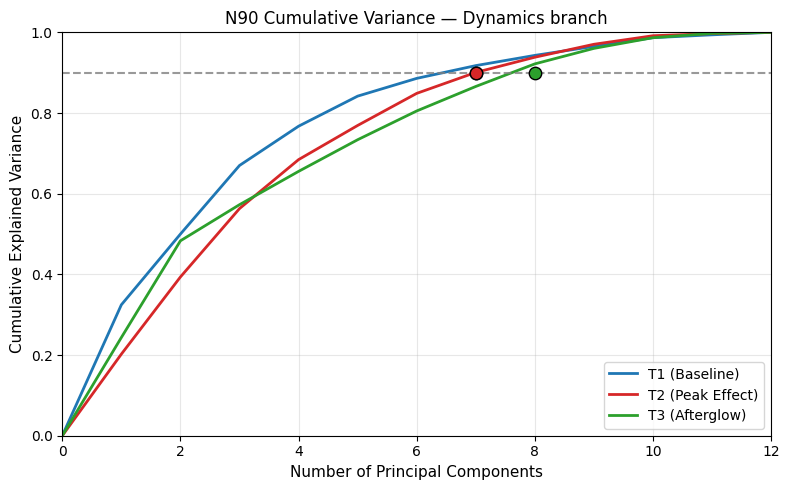

Saved: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p3_r1\N90_Curve_Dynamics.png


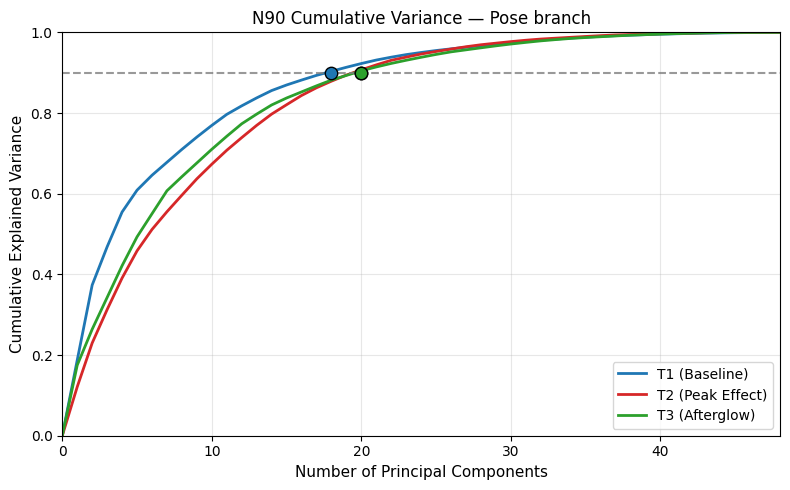

Saved: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p3_r1\N90_Curve_Pose.png


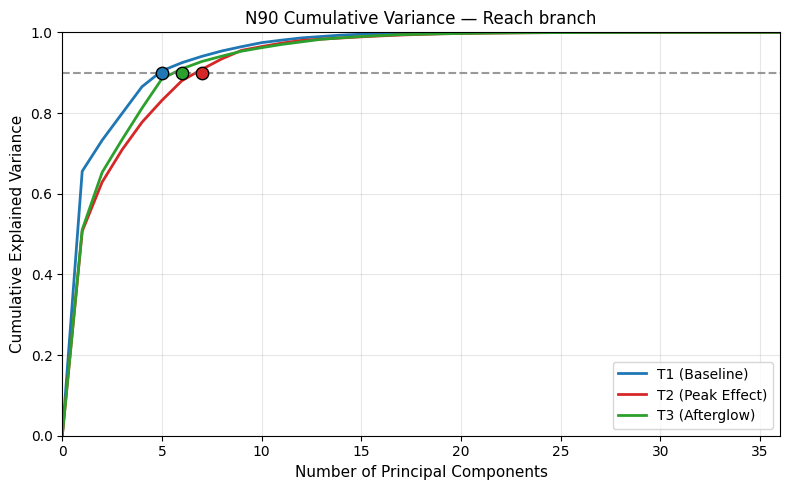

Saved: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p3_r1\N90_Curve_Reach.png


In [19]:
# ============================================================
# N90 Cumulative Variance Curves — one plot per branch (300 DPI PNG in results/)
# ============================================================
from EDA_PCA import plot_multi_session_variance_curves
import matplotlib.pyplot as plt

# Ensure run-specific results dir exists (set in Phase 1; fallback if cell run alone)
try:
    results_dir
except NameError:
    results_dir = (Path(PROJECT_ROOT) / "results" / f"Subject_{SUBJECT_ID}").resolve()
results_dir.mkdir(parents=True, exist_ok=True)

branch_names = {"dynamics": "Dynamics", "pose": "Pose", "reach": "Reach"}

for branch_key in ("dynamics", "pose", "reach"):
    save_path = results_dir / f"N90_Curve_{branch_names[branch_key]}.png"
    fig = plot_multi_session_variance_curves(
        pca_results, prepared, branch_key, save_path=save_path, dpi=300
    )
    plt.show(fig)
    plt.close(fig)
    print(f"Saved: {save_path}")

## Phase 4: Anatomical Loadings (The "Who" of the Movement)

Identify the **Top 5 joints** contributing to variance in each branch: Anatomical Contribution Index = sum of squared loadings for PC1, PC2, PC3 per feature, aggregated by joint, normalized to 100%. Use this to check whether complexity is driven by axial (Spine/Neck) or peripheral (Hands/Feet) joints.

In [20]:
# ============================================================
# Phase 4: Joint loadings — Top 5 contributors per branch
# ============================================================
from EDA_PCA import calculate_joint_loadings

loadings_results = calculate_joint_loadings(pca_results)

branch_display = {"dynamics": "Dynamics (ω)", "pose": "Pose (q)", "reach": "Reach (XYZ)"}

# Top 5 Joint Contributors Table: Branch | Top 1 Joint (%) | Top 2 Joint (%) | ... | Top 5 Joint (%)
rows = []
for key in ("dynamics", "pose", "reach"):
    r = loadings_results.get(key)
    if not r:
        continue
    joints = r["top5_joints"]
    pcts = r["top5_pct"]
    row = {"Branch": branch_display[key]}
    for i in range(5):
        label = f"Top {i+1} Joint (%)"
        if i < len(joints):
            row[label] = f"{joints[i]} ({pcts[i]}%)"
        else:
            row[label] = ""
    rows.append(row)
df_loadings = pd.DataFrame(rows)
display(df_loadings)

,Branch,Top 1 Joint (%),Top 2 Joint (%),Top 3 Joint (%),Top 4 Joint (%),Top 5 Joint (%)
0,Dynamics (ω),Head (9.35%),LeftHand (8.93%),RightHand (8.88%),LeftShoulder (8.76%),RightShoulder (8.75%)
1,Pose (q),RightShoulder (10.18%),LeftShoulder (9.25%),RightForeArm (9.2%),RightHand (8.81%),LeftHand (8.8%)
2,Reach (XYZ),RightForeArm (8.83%),LeftForeArm (8.66%),RightHand (8.43%),RightShoulder (8.38%),LeftShoulder (8.37%)


In [21]:
# ============================================================
# Phase 4 (upgrade): Session-specific loadings — Longitudinal Joint Shift Table
# ============================================================
from EDA_PCA import calculate_session_joint_loadings, longitudinal_joint_shift_table

session_loadings = calculate_session_joint_loadings(pca_results, prepared)
shift_rows = longitudinal_joint_shift_table(session_loadings, top_n=10)

df_shift = pd.DataFrame(shift_rows)
# Map branch key to display name
branch_display = {"dynamics": "Dynamics (ω)", "pose": "Pose (q)", "reach": "Reach (XYZ)"}
if "Branch" in df_shift.columns:
    df_shift["Branch"] = df_shift["Branch"].map(lambda k: branch_display.get(k, k))
# Dynamic column order: Branch | Joint | {tp} % ... | Change (...)
# (column names are now set dynamically by longitudinal_joint_shift_table based on available timepoints)
_fixed = ["Branch", "Joint"]
_dynamic = [c for c in df_shift.columns if c not in _fixed]
df_shift = df_shift[_fixed + _dynamic]
display(df_shift)

,Branch,Joint,T1 %,T2 %,T3 %,Change (T2-T1)
0,Dynamics (ω),LeftArm,8.95,7.51,9.36,-1.45
1,Dynamics (ω),RightShoulder,8.88,7.76,8.52,-1.12
2,Dynamics (ω),RightArm,8.92,7.80,9.48,-1.12
3,Dynamics (ω),RightHand,7.98,9.00,7.42,1.02
4,Dynamics (ω),Neck,7.67,8.66,8.37,0.99
5,Dynamics (ω),LeftForeArm,8.27,9.22,7.78,0.95
6,Dynamics (ω),LeftHand,8.09,8.83,7.43,0.74
7,Dynamics (ω),Head,7.66,8.37,8.52,0.71
8,Dynamics (ω),LeftShoulder,8.68,8.11,8.33,-0.56
9,Dynamics (ω),Spine,8.43,8.12,8.20,-0.30


### Whole-System Statistics & Longitudinal Strategy Table

Per-branch indices using the full joint set: variance is reconstructed from the global PCA (Y = X·V), attributed to features via squared loadings scaled by session PC variance, then aggregated by joint. **Gini** (inequality), **Shannon entropy** (diversity), **Axial-Peripheral ratio** (core vs. limbs), **Sparseness** (% joints &lt;1% contribution).

In [22]:
# ============================================================
# Longitudinal Strategy Table & Index Legend
# ============================================================
from EDA_PCA import (
    calculate_whole_system_stats,
    longitudinal_strategy_table,
    get_index_definitions,
)

stats_results = calculate_whole_system_stats(pca_results, prepared)
strategy_rows = longitudinal_strategy_table(stats_results)

df_strategy = pd.DataFrame(strategy_rows)
branch_display = {"dynamics": "Dynamics (ω)", "pose": "Pose (q)", "reach": "Reach (XYZ)"}
if "Branch" in df_strategy.columns:
    df_strategy["Branch"] = df_strategy["Branch"].map(lambda k: branch_display.get(k, k))
# Dynamic column order: Branch | Metric | {tp1} | {tp2} | ... | % Change (...)
# (column names are now set dynamically by longitudinal_strategy_table based on available timepoints)
_fixed = ["Branch", "Metric"]
_dynamic = [c for c in df_strategy.columns if c not in _fixed]
df_strategy = df_strategy[_fixed + _dynamic]
display(df_strategy)

# Index Legend (PCA-logic explanations)
print("\n" + "=" * 60 + "\nIndex Legend\n" + "=" * 60)
for name, definition in get_index_definitions().items():
    print(f"\n• {name}\n  {definition}")

,Branch,Metric,T1,T2,T3,% Change (T1 vs T2)
0,Dynamics (ω),Gini,0.0296,0.0350,0.0396,18.44
1,Dynamics (ω),Shannon,2.4835,2.4830,2.4823,-0.02
2,Dynamics (ω),AxialPeripheral,0.9786,0.9307,1.0870,-4.89
3,Dynamics (ω),Sparseness,0.0000,0.0000,0.0000,0.00
4,Pose (q),Gini,0.0765,0.0612,0.0236,-20.03
5,Pose (q),Shannon,2.4755,2.4791,2.4840,0.14
6,Pose (q),AxialPeripheral,0.7474,1.1700,1.0742,56.54
7,Pose (q),Sparseness,0.0000,0.0000,0.0000,0.00
8,Reach (XYZ),Gini,0.0382,0.0404,0.0177,5.82
9,Reach (XYZ),Shannon,2.4825,2.4820,2.4842,-0.02



Index Legend

• Gini Coefficient (Inequality)
  Calculated by reconstructing session variance from the full PCA weight matrix. A low Gini in T2 indicates that the 'movement budget' has shifted from being dominated by a few joints to a more democratic, whole-body integration.

• Shannon Entropy (Diversity)
  Measures the information density of the joint-variance distribution. Based on the probability of each joint contributing to the total movement. Higher entropy in T2 suggests the motor system is exploring a more diverse and less predictable set of joint combinations.

• Axial-Peripheral Ratio (Core vs. Limbs)
  A comparison of 'Central' (Spine/Neck/Hips) vs. 'Distal' (Hands/Feet) variance loadings. An increase in T2 suggests the subject has shifted toward 'embodied' movement, where the core of the body drives the behavioral complexity rather than just the extremities.

• Sparseness (System Activation)
  The percentage of the body that remains 'silent' (<1% contribution). Lower spars

In [23]:
# ============================================================
# Numerical Results Archive — Phase 0 to 5 Table Export
# ============================================================
from pathlib import Path
from EDA_PCA import save_numerical_tables_html

# Compile all statistical tables with clear titles (use globals() to avoid NameError if a cell was skipped)
_g = globals()
tables = [
    ("Phase 0: Numerical Verification Table", _g.get("df_verify")),
    ("Phase 1: Scaling Summary Table", _g.get("df_scaling")),
    ("Phase 2: Variance Table", _g.get("df_variance")),
    ("Phase 3: N90 Trend Table", _g.get("df_n90")),
    ("Phase 3: Volume Trend Table", _g.get("df_volume")),
    ("Phase 4: Joint Loadings (Top 5 per branch)", _g.get("df_loadings")),
    ("Phase 4: Session Loadings (Longitudinal)", _g.get("df_shift")),
    ("Phase 5: Longitudinal Strategy Table", _g.get("df_strategy")),
]
tables = [(t, d) for t, d in tables if d is not None]

# Save to run-specific results directory (results_dir set in Phase 1)
out_path = results_dir / f"Subject_{SUBJECT_ID}_Numerical_Tables.html"
n_saved, size_bytes = save_numerical_tables_html(
    tables, out_path, subject_id=str(SUBJECT_ID),
    available_timepoints=AVAILABLE_TIMEPOINTS,
)

print(f"Numerical archive saved: {n_saved} tables, {size_bytes:,} bytes ({size_bytes/1024:.1f} KB)")
print(f"Path: {out_path}")

Numerical archive saved: 8 tables, 14,193 bytes (13.9 KB)
Path: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p3_r1\Subject_651_p3_r1_Numerical_Tables.html


## Phase 5: 12-Plot Dashboard

4×3 grid: **Columns** — (1) Spatial expansion (3D PCA), (2) Complexity (N90 & Volume), (3) Strategy (Gini & Entropy), (4) Anatomy (Top 5 joints T2). **Rows** — Dynamics (ω), Pose (q), Reach (XYZ). Index Legend is printed below for interpreting Systems changes.

In [24]:
# ============================================================
# Phase 5: Dashboard Visualization — COMMENTED OUT (no dual-axis 4x3 dashboard)
# ============================================================
# from pathlib import Path
# from EDA_PCA import create_results_dashboard, save_clean_dashboard_html, get_index_definitions
#
# try:
#     PROJECT_ROOT
# except NameError:
#     import os
#     PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(os.getcwd())
#
# out_path = results_dir / f"Subject_{SUBJECT_ID}_Clean_Analysis.html"
# fig = create_results_dashboard(
#     pca_results=pca_results,
#     n90_results=n90_results,
#     volume_results=volume_results,
#     stats_results=stats_results,
#     session_loadings=session_loadings,
#     output_path=None,
# )
# fig.update_layout(barmode="group")
# save_clean_dashboard_html(fig, out_path, subject_id="671", available_timepoints=AVAILABLE_TIMEPOINTS)
# fig.show()
# print(f"Saved clean report: {out_path}")
# print("\n" + "=" * 60 + "\nIndex Legend\n" + "=" * 60)
# for name, definition in get_index_definitions().items():
#     print(f"\n  {name}\n  {definition}")

## Standalone Index Trend Plots

Five high-resolution line/point plots (Volume, Shannon Entropy, Gini, Sparseness, Axial–Peripheral Ratio) to visualize longitudinal shifts in behavioral strategy. Dynamics (blue), Pose (orange), Reach (green). Saved as `Trend_*.png` in `results/`; HTML report with one chapter per index (plot + explanation) is generated below.

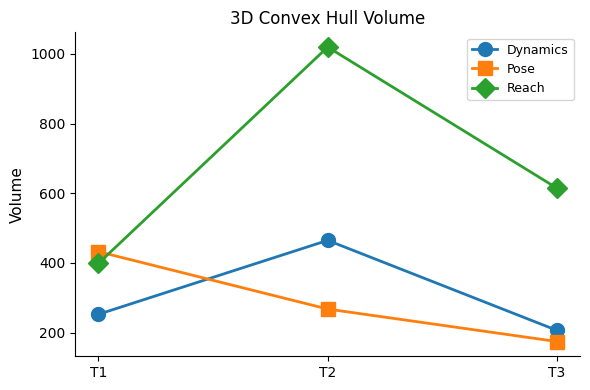

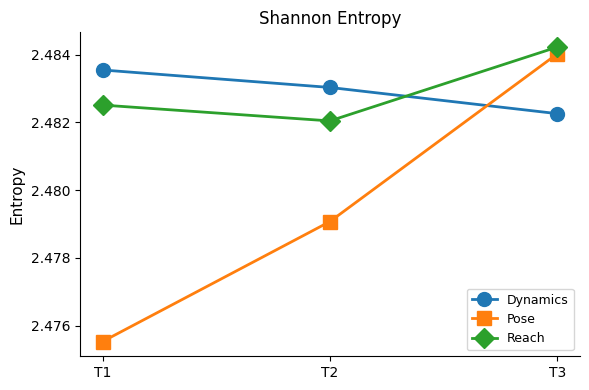

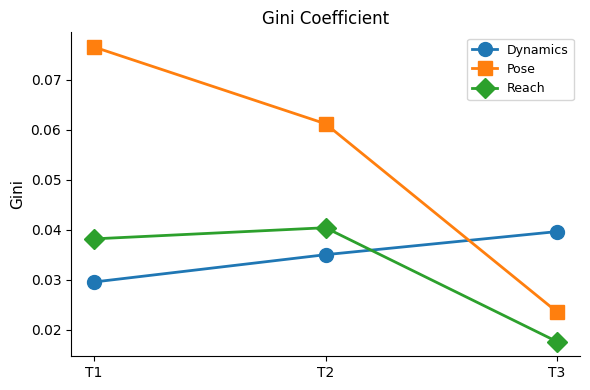

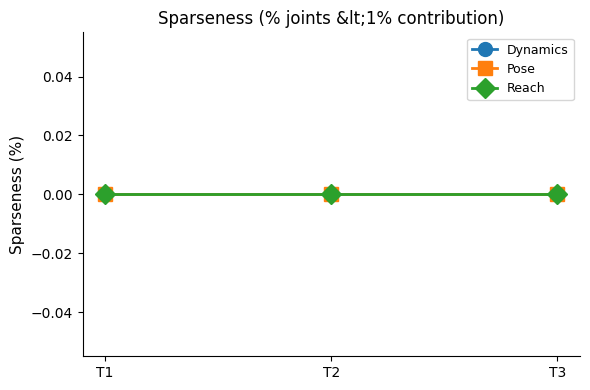

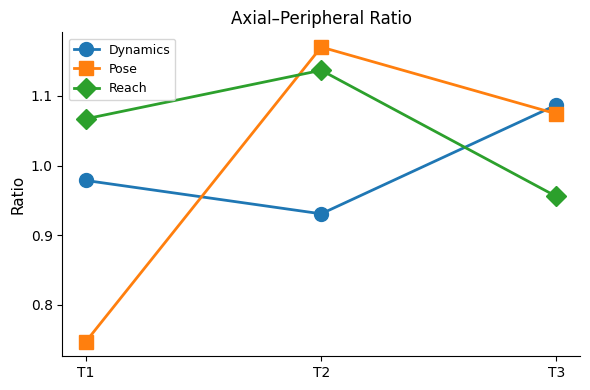

Index trend PNGs and HTML report saved in: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p3_r1
HTML: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p3_r1\Subject_651_p3_r1_Index_Trends.html


In [25]:
# ============================================================
# Index Trend Plots: generate, save PNGs, display vertically, then save HTML report
# ============================================================
from pathlib import Path
from EDA_PCA import plot_index_trends, save_index_trends_report_html
import matplotlib.pyplot as plt

# Ensure run-specific results dir exists (set in Phase 1; fallback if cell run alone)
try:
    results_dir
except NameError:
    results_dir = (Path(PROJECT_ROOT) / "results" / f"Subject_{SUBJECT_ID}").resolve()
results_dir.mkdir(parents=True, exist_ok=True)

trend_figures = plot_index_trends(
    stats_results, volume_results, n90_results,
    save_dir=results_dir,
    dpi=300,
)

# Display each plot vertically in the notebook
for name, fig in trend_figures:
    plt.show(fig)
    plt.close(fig)

# Save HTML report: five chapters (one per index), each with plot + explanation
index_trends_html = results_dir / f"Subject_{SUBJECT_ID}_Index_Trends.html"
save_index_trends_report_html(
    index_trends_html, results_dir, subject_id=str(SUBJECT_ID),
    available_timepoints=AVAILABLE_TIMEPOINTS,
)
print(f"Index trend PNGs and HTML report saved in: {results_dir}")
print(f"HTML: {index_trends_html}")

## Phase 6: Museum-Grade Sectional Report (Interactive Deep Dive)

One viewport-height section per branch. Each section: **Hero 3D** (left 60%), **Logic panel** (right 40%: N90, Volume, Gini/Entropy), **Anatomy footer** (joint loadings). Bootstrap container max-width 1200px, Key Findings legend at top. Saved as **Subject_671_Interactive_DeepDive.html**.

In [26]:
# ============================================================
# Phase 6: Sectional figures + Interactive Deep Dive HTML
# ============================================================
from pathlib import Path
from EDA_PCA import create_phase6_branch_figures, save_interactive_deepdive_html

try:
    results_dir
except NameError:
    results_dir = (Path(PROJECT_ROOT) / "results" / f"Subject_{SUBJECT_ID}").resolve()
results_dir.mkdir(parents=True, exist_ok=True)

branch_figures = create_phase6_branch_figures(
    pca_results, n90_results, volume_results, stats_results, session_loadings,
)
deepdive_path = results_dir / f"Subject_{SUBJECT_ID}_Interactive_DeepDive.html"
save_interactive_deepdive_html(
    branch_figures, deepdive_path, subject_id=str(SUBJECT_ID),
    available_timepoints=AVAILABLE_TIMEPOINTS,
)
print(f"Phase 6 report saved: {deepdive_path}")
# Optional: display first branch figure in notebook
branch_figures[0][2].show()

Phase 6 report saved: C:\Users\drorh\OneDrive - Mobileye\Desktop\gaga\results\Subject_651_p3_r1\Subject_651_p3_r1_Interactive_DeepDive.html
